# Data engineering

In this notebook we will take the mendeley dataset from “Steam Games Dataset: Player count history, Price history and data about games”, Wannigamage, Barlow, Lakshika & Kasmarik (UNSW Canberra), 2020. DOI 10.17632/ycy3sy3vj2.1, CC BY 4.0. https://data.mendeley.com/datasets/ycy3sy3vj2/1, and process it into a form that is useful for our model. Starting with two input features for simplicity:
- A number indicating the start of a time series (e.g. 1st of Jan is denoted 0)
- The average player count per day over 90 consecutive days.

Let's load some sample data and see how we can do this.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print(os.getcwd())


/Users/sujai/Documents/dead_game/notebooks


In [121]:
game_id = 2630
raw_player_counts = pd.read_csv("../data/mendeley/PlayerCountHistoryPart2/"+str(game_id)+".csv")
print(raw_player_counts.head())
print(raw_player_counts.info())


               Time  Playercount
0  2017-12-14 00:00        119.0
1  2017-12-14 01:00        120.0
2  2017-12-14 02:00         94.0
3  2017-12-14 03:00         91.0
4  2017-12-14 04:00         67.0
<class 'pandas.DataFrame'>
RangeIndex: 23352 entries, 0 to 23351
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Time         23352 non-null  str    
 1   Playercount  23151 non-null  float64
dtypes: float64(1), str(1)
memory usage: 365.0 KB
None


There are some null playercount values so we choose to drop these entirely.

In [122]:
player_counts = raw_player_counts.dropna(subset=["Playercount"])

We notice that this gives player counts every five minutes. This level of granularity isn't necessary for our model so we'd like to convert this into an average daily playercount. To do this we have to group columns by day and then take the mean.

In [123]:
player_counts["Time"] = player_counts["Time"].str[:10]
player_counts.head()

,Time,Playercount
0,2017-12-14,119.0
1,2017-12-14,120.0
2,2017-12-14,94.0
3,2017-12-14,91.0
4,2017-12-14,67.0


In [124]:
# groupby creates a lazy object - not a dataframe. Must apply mean() aggregation onto it to get a dataframe.
# set as_index to False to prevent "Time" becoming an index
avg_players = player_counts.groupby("Time", as_index=False).mean()
avg_players.head()

,Time,Playercount
0,2017-12-14,103.791667
1,2017-12-15,111.125000
2,2017-12-16,134.916667
3,2017-12-17,133.958333
4,2017-12-18,109.666667


Let's try to plot this data now. For this, having the time as a datetime object is better than a string so first convert.

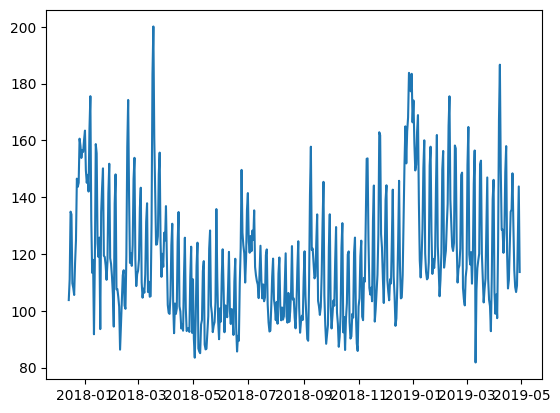

In [125]:
avg_players["Time"] = pd.to_datetime(avg_players["Time"])
window_size = 500
plt.plot(avg_players["Time"].iloc[:window_size], avg_players["Playercount"][:window_size])
plt.show()

In [126]:
# the span determines roughly how far back the exponential moving average looks 
# - for larger values it takes into account values farther in the past
ema = avg_players["Playercount"].ewm(span=14).mean()
# also check the standard moving average for comparison
roa = avg_players["Playercount"].rolling(window=8).mean()

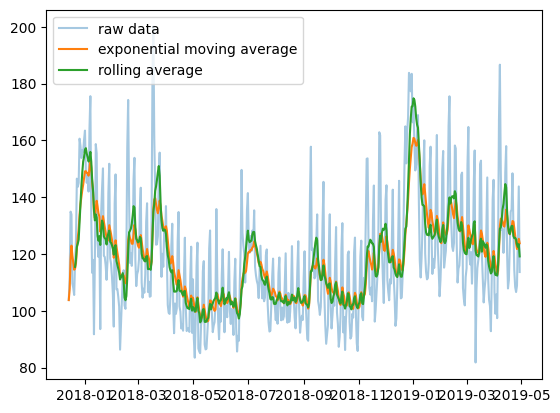

In [127]:
plt.plot(avg_players["Time"].iloc[:window_size], avg_players["Playercount"][:window_size], label='raw data', alpha=0.4)
plt.plot(avg_players["Time"].iloc[:window_size], ema.iloc[:window_size], label='exponential moving average')
plt.plot(avg_players["Time"].iloc[:window_size], roa.iloc[:window_size], label='rolling average')
plt.legend()
plt.show()

There are clear outliers where the playercount seems to be artificially low. It may be useful to remove values of the playercount that differ from the EMA by a relative amount that is larger than some percentage. We can return to this later, for now let's proceed.